In [181]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

base_path = "/Users/kdt_0900_cjs/ml/resource/dataset"
file_name = "titanic.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [182]:
drop_columns = ["PassengerId","Name","Ticket","Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)

In [183]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## 1단계, 데이터 전처리

In [184]:
# 수치형 : SibSp, Fare, Parch, Age
# 분류형 : Sex, Survived, Pclass

titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


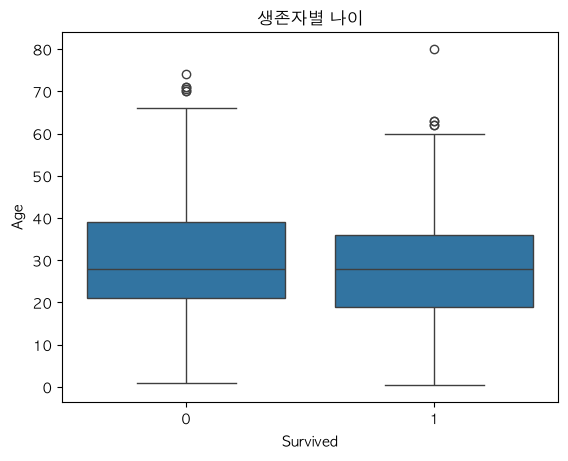

In [185]:
#생존자별 나이
sns.boxplot(titanic_df, x="Survived", y= "Age")
plt.title("생존자별 나이")
plt.show()

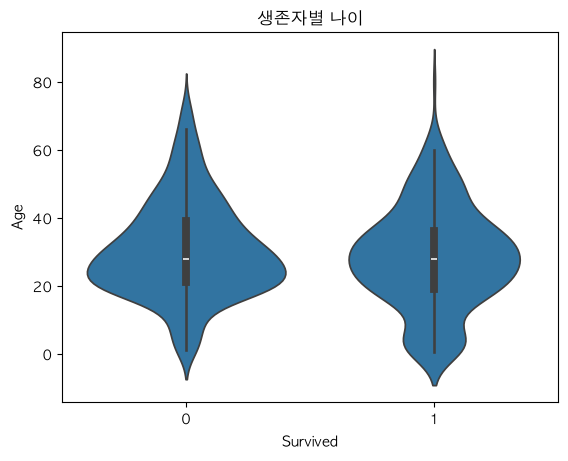

In [186]:
#생존자별 나이
sns.violinplot(titanic_df, x="Survived", y= "Age")
plt.title("생존자별 나이")
plt.show()

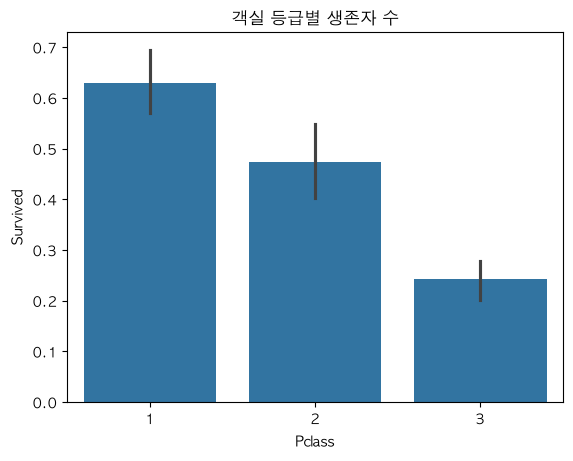

In [187]:
sns.barplot(titanic_df, x="Pclass", y="Survived")
plt.title("객실 등급별 생존자 수")
plt.show()

In [188]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [189]:
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


## 원 핫 인코딩
- 글자나, 범주형(분류형) 데이터를 컴퓨터가 좋아하는 0과 1의 행렬구조로 변환하는 전처리 기술

In [190]:
titanic_df["Sex"] = titanic_df["Sex"].map(lambda gender : {"male" : 0, "female" : 1}[gender])

In [191]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22,1,0,7.2500
1,1,1,1,38,1,0,71.2833
2,1,3,1,26,0,0,7.9250
3,1,1,1,35,1,0,53.1000
4,0,3,0,35,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,0,27,0,0,13.0000
887,1,1,1,19,0,0,30.0000
888,0,3,1,28,1,2,23.4500
889,1,1,0,26,0,0,30.0000


## 파생 변수


In [192]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,2
2,1,3,1,26,0,0,7.9250,1


### 상관관계 분석 및 다중 공선성


In [193]:
corr_matrix = titanic_df.corr(numeric_only=True)

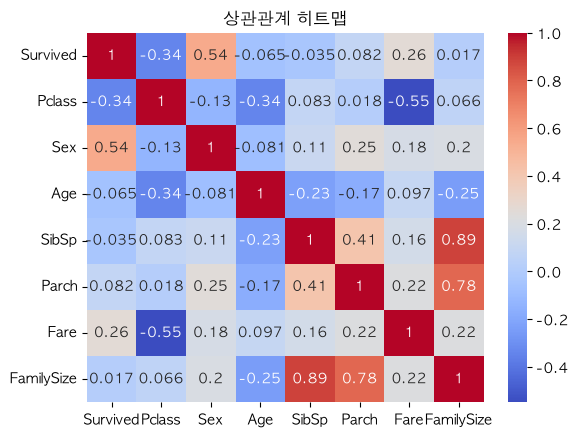

In [194]:
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [195]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [196]:
X = titanic_df.drop("Survived", axis=1)
X.head(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,3,0,22,1,0,7.2500,2
1,1,1,38,1,0,71.2833,2
2,3,1,26,0,0,7.9250,1


In [197]:
y= titanic_df["Survived"]
y.head(3)

0    0
1    1
2    1
Name: Survived, dtype: int64

In [198]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize'], dtype='str')


/var/folders/xm/9m5jkr551jxg7scv_lxlytdm0000gn/T/ipykernel_69493/602452674.py:1: UserWarning: The design matrix is poorly conditioned (condition number=1.07e+16). VIF calculations may be numerically unstable.
  vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
/Users/chaejinseong/anaconda3/envs/machine_learning/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


[np.float64(1.6794806571515302),
 np.float64(1.0999293570782829),
 np.float64(1.2109866595086367),
 np.float64(1000799917193443.5),
 np.float64(1000799917193443.5),
 np.float64(1.5928864776687555),
 np.float64(1000799917193443.5)]

### VIF
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다.   
  즉 독립변수와 독립련수와의 관계를 의미하며 다른 변수들과의 조합을 수치로 표현한 것이다.

### VIF 해석
- VIF < 5 : 문제없음
- 5 <= VIF <= 10 : 주의
- VIF > 10 : 다중 공전성 의심(조치, 삭제, 고려)

In [199]:
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis = 1)

In [200]:
titanic_df

,Survived,Pclass,Sex,Age,Fare,FamilySize
0,0,3,0,22,7.2500,2
1,1,1,1,38,71.2833,2
2,1,3,1,26,7.9250,1
3,1,1,1,35,53.1000,2
4,0,3,0,35,8.0500,1
...,...,...,...,...,...,...
886,0,2,0,27,13.0000,1
887,1,1,1,19,30.0000,1
888,0,3,1,28,23.4500,4
889,1,1,0,26,30.0000,1


In [201]:
X = titanic_df.drop("Survived", axis = 1)
X.head()

,Pclass,Sex,Age,Fare,FamilySize
0,3,0,22,7.2500,2
1,1,1,38,71.2833,2
2,3,1,26,7.9250,1
3,1,1,35,53.1000,2
4,3,0,35,8.0500,1


In [202]:
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [203]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize'], dtype='str')


[np.float64(1.6793627154980004),
 np.float64(1.0792936783037332),
 np.float64(1.209897141451446),
 np.float64(1.589377177831001),
 np.float64(1.1907253661505575)]

In [204]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)


In [205]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계, 모델 준비

In [206]:
from sklearn.linear_model import LogisticRegression

In [207]:
lr = LogisticRegression()

## 3단계, 모델 학습

In [208]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

## 4단계, 모델 평가

In [209]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

print(f"훈련데이터 정확도 점수 : {train_score}")
print(f"테스트 데이터 정확도 점수 : {test_score}")

훈련데이터 정확도 점수 : 0.7991573033707865
테스트 데이터 정확도 점수 : 0.7877094972067039


### 시그모이드 함수 (Sigmoid Function)
수학자들이 만든 특수한 함수로, 여기에 어떤 숫자를 넣든 무조건 **0과 1 사이의 소수점(확률)**으로 꽉 눌러서 변환해 줍니다.

$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fsib2q%2FbtsDJkfaBMy%2FAAAAAAAAAAAAAAAAAAAAAJwQd20TZhIxLx58GiUJdYxCLH_4xkSt66vEea-TnEkx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZyqh5kd4SOqkuF96VWHHU3%252B91F0%253D)

In [210]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0])

In [211]:
print(f"모델의 예측 확율 : {lr.predict_proba(X_test_scaled)[:5]}")
print(f"모델의 예측 값 : {y_pred[:5]}")
print(f"모델의 정답 : {y_test.values[:5]}")

모델의 예측 확율 : [[0.88975595 0.11024405]
 [0.95206629 0.04793371]
 [0.04508301 0.95491699]
 [0.88520626 0.11479374]
 [0.90132407 0.09867593]]
모델의 예측 값 : [0 0 1 0 0]
모델의 정답 : [0 0 1 0 0]


In [212]:
print(f"테스트 정확도 : {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도 : {accuracy_score(y_pred=y_pred, y_true = y_test)}")

테스트 정확도 : 0.7991573033707865
테스트 정확도 : 0.7877094972067039


In [213]:
X_train.head(1)

,Pclass,Sex,Age,Fare,FamilySize
413,2,0,28,0.0,1


### ROC-Curve
- 이진 분류 모델의 성능을 임계값을 기준에서 시각적으로 평가한 그래프 입니다.
- X축(특이도) - TPR : 실제 양성 중 모델이 양성으로 맞춘 비율
- y축(민감도) - FPR : 실제 음성 중 모델이 양성으로 잘못 맞춘 비율

In [214]:
from sklearn.metrics import RocCurveDisplay

In [ ]:
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

In [ ]:
# 각 가중치 확인
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by = "Coef", ascending=False)

coef_df

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    display_labels=["사망(0)", "생존(1)"],
    cmap="Blues"
)

plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()

In [ ]:
print(classification_report(y_pred, y_test))